Unified MLP Experiments

This notebook loads the merged dataset once and then runs multiple MLP experiments (all features, EEG-only, pitch-only, speech-only, etc.) with 5-fold cross-validation.

Run cells top-to-bottom to reproduce the individual results without opening multiple notebooks.

In [11]:
import sys
import os
import pickle
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold
import matplotlib.pyplot as plt
from scipy import signal
try:
    import librosa
except ImportError:
    librosa = None

# Select device (MPS on Apple, else CUDA if available, else CPU)
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")

Using device: cuda


In [12]:
# Load and inner-merge all modality files once (same as in existing notebooks)
files = {
    "action": "epoched_action.pkl",
    "location": "epoched_location.pkl",
    "pupil": "epoched_pupil.pkl",
    "speech": "epoched_speech_event.pkl",
    "performance": "team_performance.pkl",
    "eeg": "epoched_eeg.pkl",
    "rawl_ocation": "epoched_raw_location.pkl",
}

base_path  = "../../data"

dfs = {}
for name, filename in files.items():
    if os.path.exists(os.path.join(base_path, filename)):
        dfs[name] = pd.read_pickle(os.path.join(base_path, filename))

join_keys = ["teamID", "sessionID", "trialID", "ringID"]

if len(dfs) == 0:
    raise RuntimeError("No input pickle files were found in the working directory.")

# Inner join all dataframes on the common keys
_df_list = list(dfs.values())
final = _df_list[0]
for i in range(1, len(_df_list)):
    right_df = _df_list[i]
    cols_to_use = [
        col for col in right_df.columns
        if col not in final.columns or col in join_keys
    ]
    final = pd.merge(final, right_df[cols_to_use], on=join_keys, how="inner")

print(f"Final merged shape: {final.shape}")
final.head()

Final merged shape: (7322, 25)


,teamID,sessionID,trialID,ringID,yawAction,pitchAction,thrustAction,communication,difficulty,location,...,pitchSpeech,thrustSpeech,ringX,ringY,ringZ,yawEEG,pitchEEG,thrustEEG,time,startTime
0,T14,S2,0,0,"[0.0, 0.0, 0.0, 0.0, -1.0, -1.0, -1.0, -1.0, -...","[-1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...",No,Easy,"[[-28260.53, -27937.451, -27661.686, -27297.01...",...,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.0,0.000,0.000,"[[-1.2739452254275653e-06, 1.7328447655377687e...","[[7.997057125618852e-07, -1.0576951561190639e-...","[[-1.4296975857124375e-05, -1.0186087329281338...","[11.270414846760104, 11.282638724034769, 11.29...",11.270415
1,T14,S2,2,0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[-1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1....",No,Easy,"[[-13113.82, -12990.257, -12895.533, -12772.19...",...,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.0,0.000,0.000,"[[4.395903396301527e-06, 7.007500727628696e-06...","[[-1.2251334199008667e-05, -1.1901307884547594...","[[1.4219442920497338e-05, 1.4984248431738854e-...","[42.661331686758786, 42.67355556403345, 42.685...",42.661332
2,T14,S2,2,1,"[-1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1....","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[-1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1....",No,Easy,"[[33795.082, 33932.094, 34055.836, 34170.016, ...",...,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",50000.0,450.136,-267.660,"[[2.9960644766051597e-07, -9.47046509505393e-0...","[[1.076344127682584e-05, 8.523591762754229e-06...","[[-2.634237839599604e-06, -3.5740650037458362e...","[47.8931511600822, 47.90537503735686, 47.91759...",47.893151
3,T14,S2,2,2,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",No,Easy,"[[83677.734, 83873.05, 84046.664, 84241.86, 84...",...,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",100000.0,605.902,612.104,"[[-1.8171926146275147e-06, -1.2458894215753461...","[[-6.8169789679026124e-06, -2.0143394178028022...","[[-1.985301732448503e-07, -1.136889138247305e-...","[51.474747201413265, 51.48697107868793, 51.499...",51.474747
4,T14,S2,2,3,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",No,Easy,"[[133052.98, 133261.53, 133437.67, 133620.19, ...",...,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",150000.0,-347.252,-748.143,"[[4.161745803068577e-06, 4.489325670785023e-06...","[[3.832639766261056e-06, 2.56367524969258e-06,...","[[-1.5747211286062064e-06, 4.02462493495194e-0...","[55.20302977002575, 55.215253647300415, 55.227...",55.20303


In [13]:
# Feature extraction (single pass over `final`, similar to disp1.ipynb)

join_keys = ['teamID', 'sessionID', 'trialID', 'ringID']
first_row = final.iloc[0]

# Auto-detect all time-series feature columns (lists/arrays) excluding join keys
feature_cols = []
for col in final.columns:
    if isinstance(first_row[col], (list, np.ndarray)) and col not in join_keys:
        feature_cols.append(col)

print(f"--> Found {len(feature_cols)} feature columns: {feature_cols}")

# EEG: FFT power in 64 equal bins from 0 Hz to Nyquist (chan_locs.sfp channel order).
EEG_FS = 256  # Hz (as specified)
EEG_N_BINS = 64

# Lines 13, 17, 19 in chan_locs.sfp: Fz, POz, Cz (0-based indices in 20-channel arrays).
EEG_CHANNEL_LABEL_TO_INDEX = {
    'Fz': 12,
    'POz': 16,
    'Cz': 18,
}
EEG_SELECTED_CHANNELS = ['Fz', 'POz', 'Cz']

# Pupil: frequency-domain features only below 1 Hz (adjust if your pupil sampling rate differs).
PUPIL_FS = 100  # Hz
PUPIL_N_BINS = 64
PUPIL_MAX_HZ = 1.0


def _fft_power_bins_1d(x: np.ndarray, fs: float, n_bins: int) -> np.ndarray:
    """Mean FFT power in `n_bins` equal-width bins from 0 Hz to Nyquist."""
    x = np.asarray(x, dtype=float).ravel()
    x = np.nan_to_num(x)
    out = np.full(n_bins, np.nan, dtype=float)
    if x.size < 64:
        return out
    n_fft = int(min(1024, x.size))
    n_fft = max(64, n_fft)
    power = np.abs(np.fft.rfft(x, n=n_fft)) ** 2
    freqs = np.fft.rfftfreq(n_fft, d=1.0 / fs)
    nyq = fs / 2.0
    bin_edges = np.linspace(0.0, nyq, n_bins + 1)
    for k in range(n_bins):
        lo, hi = bin_edges[k], bin_edges[k + 1]
        mask = (freqs >= lo) & (freqs < hi) if k < n_bins - 1 else (freqs >= lo) & (freqs <= hi)
        if not np.any(mask):
            out[k] = 0.0
        else:
            out[k] = float(np.mean(power[mask]))
    return out


def _pupil_fft_bins_under_1hz(x: np.ndarray, fs: float, f_max: float, n_bins: int) -> np.ndarray:
    """Mean FFT power in `n_bins` equal-width bins from 0 Hz up to min(f_max, Nyquist)."""
    x = np.asarray(x, dtype=float).ravel()
    x = np.nan_to_num(x)
    out = np.full(n_bins, np.nan, dtype=float)
    if x.size < 64:
        return out
    n_fft = int(min(2048, x.size))
    n_fft = max(128, n_fft)
    power = np.abs(np.fft.rfft(x, n=n_fft)) ** 2
    freqs = np.fft.rfftfreq(n_fft, d=1.0 / fs)
    nyq = fs / 2.0
    hi_edge = min(float(f_max), nyq)
    bin_edges = np.linspace(0.0, hi_edge, n_bins + 1)
    for k in range(n_bins):
        lo, hi = bin_edges[k], bin_edges[k + 1]
        # Strictly below f_max (e.g. < 1 Hz) in the last bin
        mask = (freqs >= lo) & (freqs < hi)
        if not np.any(mask):
            out[k] = 0.0
        else:
            out[k] = float(np.mean(power[mask]))
    return out


def extract_stats(row):
    stats = {}

    # Encode difficulty (Easy=1, Medium=2, Hard=3)
    diff_map = {'Easy': 1, 'Medium': 2, 'Hard': 3}
    stats['difficulty_score'] = diff_map.get(row.get('difficulty', 'Medium'), 2)

    # Flatten time-series data into summary stats
    for col in feature_cols:
        val = row[col]
        try:
            data = np.array(val, dtype=float)
        except Exception:
            continue

        if data.size == 0:
            continue

        is_eeg = 'eeg' in col.lower()
        is_pupil = 'pupil' in col.lower()

        if is_eeg:
            if data.ndim == 1:
                bins = _fft_power_bins_1d(data, fs=EEG_FS, n_bins=EEG_N_BINS)
                for i in range(EEG_N_BINS):
                    stats[f'{col}_bin{i}'] = bins[i]
            elif data.ndim == 2:
                for ch_label in EEG_SELECTED_CHANNELS:
                    ch_idx = EEG_CHANNEL_LABEL_TO_INDEX[ch_label]
                    if ch_idx >= data.shape[0]:
                        continue
                    ch = data[ch_idx, :]
                    bins = _fft_power_bins_1d(ch, fs=EEG_FS, n_bins=EEG_N_BINS)
                    for i in range(EEG_N_BINS):
                        stats[f'{col}_{ch_label}_bin{i}'] = bins[i]
        elif is_pupil:
            if data.ndim == 1:
                bins = _pupil_fft_bins_under_1hz(data, fs=PUPIL_FS, f_max=PUPIL_MAX_HZ, n_bins=PUPIL_N_BINS)
                for i in range(PUPIL_N_BINS):
                    stats[f'{col}_lf_bin{i}'] = bins[i]
            elif data.ndim == 2:
                for ch_idx in range(data.shape[0]):
                    bins = _pupil_fft_bins_under_1hz(data[ch_idx, :], fs=PUPIL_FS, f_max=PUPIL_MAX_HZ, n_bins=PUPIL_N_BINS)
                    for i in range(PUPIL_N_BINS):
                        stats[f'{col}_ch{ch_idx}_lf_bin{i}'] = bins[i]
        else:
            # Non-EEG, non-pupil columns: retain mean/std summary
            if data.ndim == 1:
                stats[f'{col}_mean'] = np.nanmean(data)
                stats[f'{col}_std'] = np.nanstd(data)
            elif data.ndim == 2:
                means = np.nanmean(data, axis=1)
                stds = np.nanstd(data, axis=1)
                for i in range(len(means)):
                    stats[f'{col}_ch{i}_mean'] = means[i]
                    stats[f'{col}_ch{i}_std'] = stds[i]

    return pd.Series(stats)

print("Extracting trial-level features from raw data... (This may take a minute)")
features_df = final.apply(extract_stats, axis=1)

# Build trial-level dataframe and target (same logic as disp1.ipynb)
full_df = pd.concat([final[join_keys], features_df], axis=1)
trial_df = full_df.groupby(['teamID', 'sessionID', 'trialID']).mean().reset_index()

rings_count = (
    final.groupby(['teamID', 'sessionID', 'trialID'])
    .size()
    .reset_index(name='rings_passed')
)

trial_data = pd.merge(trial_df, rings_count, on=['teamID', 'sessionID', 'trialID'])
trial_data['weighted_score'] = trial_data['rings_passed'] * trial_data['difficulty_score']

print(f"Dataset prep complete: {trial_data.shape[0]} unique trials.")
trial_data.head()

--> Found 14 feature columns: ['yawAction', 'pitchAction', 'thrustAction', 'location', 'yawPupil', 'pitchPupil', 'thrustPupil', 'yawSpeech', 'pitchSpeech', 'thrustSpeech', 'yawEEG', 'pitchEEG', 'thrustEEG', 'time']
Extracting trial-level features from raw data... (This may take a minute)
Dataset prep complete: 1074 unique trials.


,teamID,sessionID,trialID,ringID,difficulty_score,yawAction_mean,yawAction_std,pitchAction_mean,pitchAction_std,thrustAction_mean,...,thrustEEG_Cz_bin58,thrustEEG_Cz_bin59,thrustEEG_Cz_bin60,thrustEEG_Cz_bin61,thrustEEG_Cz_bin62,thrustEEG_Cz_bin63,time_mean,time_std,rings_passed,weighted_score
0,T14,S2,0,0.0,1.0,-0.077778,0.600514,0.033333,0.525991,1.000000,...,3.173388e-11,3.148647e-11,3.129091e-11,3.111835e-11,3.100778e-11,3.095266e-11,14.069683,1.619683,1,1.0
1,T14,S2,2,4.5,1.5,-0.080000,0.243844,0.031111,0.176860,-0.353333,...,5.619826e-11,5.585403e-11,5.557400e-11,5.537000e-11,5.522763e-11,5.514706e-11,63.676010,2.116882,10,15.0
2,T14,S2,4,2.0,1.0,0.004444,0.485669,0.008889,0.440810,0.526667,...,7.673865e-10,7.622723e-10,7.582362e-10,7.551478e-10,7.530755e-10,7.518903e-10,124.443960,2.144759,5,5.0
3,T14,S2,5,1.5,1.0,0.061111,0.217370,0.044444,0.252340,0.177778,...,8.056609e-11,8.004273e-11,7.963313e-11,7.932904e-11,7.911665e-11,7.900229e-11,175.944378,1.967263,4,4.0
4,T14,S2,8,0.0,1.0,-0.077778,0.581717,-0.066667,0.249444,1.000000,...,1.764221e-10,1.753296e-10,1.744465e-10,1.737988e-10,1.733547e-10,1.730988e-10,230.817363,1.693786,1,1.0


In [ ]:
# Shared MLP model and 5-fold CV helper

class BasicMLP(nn.Module):
    def __init__(self, input_size: int):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
        )

    def forward(self, x):
        return self.layers(x)


def build_X_y(trial_data: pd.DataFrame, mode: str):
    """Build feature matrix X and target y for a given mode.

    mode can be:
    - simple: 'all', 'eeg', 'pitch', 'speech', 'pupil', 'yaw', 'thrust', 'action', etc.
    - composite: 'eeg_pupil_speech', 'eeg_pupil', 'eeg_speech', 'pupil_speech',
      'actions_speech', 'eeg_actions_pupil', 'eeg_actions_pupil_speech'.

    NOTE: EEG/pupil FFT bin features can explode dimensionality (64 bins * channels * signals).
    For the MLP only, we pool 64-bin features into fewer "super-bins" to reduce overfitting.
    """
    base_exclude = ['teamID', 'sessionID', 'trialID', 'ringID', 'rings_passed', 'weighted_score']

    import re

    BIN_POOL = 8  # 64 bins -> 8 pooled bins (mean within each group)

    def _pool_bin_columns(df: pd.DataFrame, cols: list[str]):
        """Pool *_bin{0..63} and *_lf_bin{0..63} into BIN_POOL groups for MLP."""
        bin_pat = re.compile(r"^(.*?)(?:_lf)?_bin(\d+)$", re.IGNORECASE)

        groups = {}  # base -> {idx: colname}
        keep_cols = []
        for c in cols:
            m = bin_pat.match(c)
            if m:
                base = m.group(1)
                idx = int(m.group(2))
                groups.setdefault(base, {})[idx] = c
            else:
                keep_cols.append(c)

        pooled_arrays = []
        pooled_names = []
        for base, idx_to_col in groups.items():
            # Only pool if it looks like a full bin set.
            if len(idx_to_col) < 8:
                keep_cols.extend(idx_to_col.values())
                continue

            # Assemble in bin order with NaN fill for missing bins
            full = []
            max_idx = max(idx_to_col)
            for i in range(max_idx + 1):
                col = idx_to_col.get(i)
                if col is None:
                    full.append(np.full((len(df),), np.nan, dtype=float))
                else:
                    full.append(df[col].to_numpy(dtype=float))
            full = np.vstack(full).T  # [n, n_bins]

            n_bins = full.shape[1]
            pool = min(BIN_POOL, n_bins)
            # pad to multiple of pool
            pad = (-n_bins) % pool
            if pad:
                full = np.hstack([full, np.full((full.shape[0], pad), np.nan, dtype=float)])
                n_bins = full.shape[1]

            step = n_bins // pool
            for g in range(pool):
                sl = full[:, g * step:(g + 1) * step]
                pooled_arrays.append(np.nanmean(sl, axis=1))
                pooled_names.append(f"{base}_bingrp{g}")

        if pooled_arrays:
            pooled_mat = np.vstack(pooled_arrays).T
            out_df = pd.DataFrame(pooled_mat, columns=pooled_names, index=df.index)
            return keep_cols, out_df
        else:
            return keep_cols, None


# Define composite modes as lists of substrings to OR together (no location)
    composite = {
        'eeg_pupil_speech': ['eeg', 'pupil', 'speech'],
        'eeg_pupil': ['eeg', 'pupil'],
        'eeg_speech': ['eeg', 'speech'],
        'pupil_speech': ['pupil', 'speech'],
        'actions_speech': ['action', 'speech'],
        'eeg_actions_pupil': ['eeg', 'action', 'pupil'],
        'eeg_actions_pupil_speech': ['eeg', 'action', 'pupil', 'speech'],
    }

    if mode == 'all':
        # Match disp1.ipynb: keep difficulty_score, exclude location (ring positions)
        X_cols = [
            c for c in trial_data.columns
            if c not in base_exclude and 'location' not in c.lower()
        ]
    elif mode in composite:
        subs = [s.lower() for s in composite[mode]]
        X_cols = [
            c
            for c in trial_data.columns
            if c not in base_exclude + ['difficulty_score']
            and any(sub in c.lower() for sub in subs)
        ]
    else:
        # Simple modality-specific substring filter
        X_cols = [
            c
            for c in trial_data.columns
            if c not in base_exclude + ['difficulty_score']
            and mode.lower() in c.lower()
        ]

    if len(X_cols) == 0:
        raise ValueError(f"No columns found for mode '{mode}'. Check that the substring exists in feature names.")

    # Pool FFT bin columns to reduce feature explosion for the MLP
    base_cols, pooled_df = _pool_bin_columns(trial_data, X_cols)
    if pooled_df is not None:
        X_df = pd.concat([trial_data[base_cols], pooled_df], axis=1)
        X_cols_out = list(X_df.columns)
    else:
        X_df = trial_data[X_cols]
        X_cols_out = X_cols

    X = X_df.to_numpy(dtype=float)
    y = trial_data['weighted_score'].to_numpy(dtype=float)
    print(f"Mode='{mode}': using {len(X_cols_out)} features, {len(y)} trials.")
    return X, y, X_cols_out


def run_mlp_cv(
    X,
    y,
    experiment_name: str,
    epochs: int = 300,
    report_accuracy: bool = False,
    X_cols = None,
    feature_weight_config = None,
):
    """Run 5-fold CV MLP and print summary stats.

    Computes per-fold MSE, RMSE, MAE, and R-squared. If report_accuracy=True,
    also computes strict/lenient accuracy (±1 / ±3), matching the all-features
    experiment in disp1.ipynb.

    If feature_weight_config is provided and has structure
      {"enabled": bool, "weights": {"eeg": w_eeg, "speech": w_speech, "action": w_action}},
    those groups are multiplicatively re-weighted (after scaling) based on
    substring matches in feature names (requires X_cols to be provided).
    """
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    fold_metrics = []
    fold_train_losses = []

    print(f"\n========== {experiment_name} ==========")
    print(f"Starting 5-fold cross-validation on {len(X)} trials (device: {device})")

    for fold, (train_idx, test_idx) in enumerate(kf.split(X)):
        print(f"\n--- [Fold {fold + 1}/5] ---")
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

        # Optional feature group weighting (e.g., make EEG/Speech lower, Action higher)
        if (
            feature_weight_config is not None
            and feature_weight_config.get("enabled", False)
            and X_cols is not None
        ):
            w_cfg = feature_weight_config.get("weights", {})
            weights = np.ones(X_train.shape[1], dtype=float)
            lower_cols = [c.lower() for c in X_cols]

            for group, w in w_cfg.items():
                g = group.lower()
                for j, cname in enumerate(lower_cols):
                    if g in cname:
                        weights[j] *= float(w)

            X_train = X_train * weights
            X_test = X_test * weights

        X_train_t = torch.tensor(X_train, dtype=torch.float32, device=device)
        y_train_t = torch.tensor(y_train, dtype=torch.float32, device=device).view(-1, 1)
        X_test_t = torch.tensor(X_test, dtype=torch.float32, device=device)
        y_test_t = torch.tensor(y_test, dtype=torch.float32, device=device).view(-1, 1)

        model = BasicMLP(input_size=X_train.shape[1]).to(device)
        optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-3)
        criterion = nn.MSELoss()
        epoch_losses = []

        for epoch in range(epochs):
            model.train()
            optimizer.zero_grad()
            outputs = model(X_train_t)
            loss = criterion(outputs, y_train_t)
            loss.backward()
            optimizer.step()
            epoch_losses.append(float(loss.item()))

            if (epoch + 1) % 50 == 0 or epoch == 0:
                print(f"  Epoch {epoch + 1:>4}/{epochs} | Train MSE: {loss.item():.4f}")

        fold_train_losses.append(epoch_losses)

        model.eval()
        with torch.no_grad():
            preds = model(X_test_t)
            mse = criterion(preds, y_test_t).item()
            rmse = float(np.sqrt(mse))
            mae = float(torch.mean(torch.abs(preds - y_test_t)).item())

            # R-squared
            y_true_np = y_test_t.cpu().numpy().reshape(-1)
            y_pred_np = preds.cpu().numpy().reshape(-1)
            ss_res = float(np.sum((y_true_np - y_pred_np) ** 2))
            ss_tot = float(np.sum((y_true_np - np.mean(y_true_np)) ** 2))
            r2 = 0.0 if ss_tot == 0.0 else 1.0 - ss_res / ss_tot

            metrics = {
                'mse': mse,
                'rmse': rmse,
                'mae': mae,
                'r2': r2,
            }

            if report_accuracy:
                errors = torch.abs(preds.view(-1) - y_test_t.view(-1))
                strict_acc = float((errors <= 1.0).sum().item() / len(y_test_t) * 100.0)
                lenient_acc = float((errors <= 3.0).sum().item() / len(y_test_t) * 100.0)
                metrics['strict_acc'] = strict_acc
                metrics['lenient_acc'] = lenient_acc
                print(
                    f"  -> Fold {fold + 1} | MSE: {mse:.3f} | RMSE: {rmse:.3f} | "
                    f"MAE: {mae:.3f} | R^2: {r2:.3f} | "
                    f"Strict Acc (±1): {strict_acc:.1f}% | Lenient Acc (±3): {lenient_acc:.1f}%"
                )
            else:
                print(
                    f"  -> Fold {fold + 1} | MSE: {mse:.3f} | RMSE: {rmse:.3f} | "
                    f"MAE: {mae:.3f} | R^2: {r2:.3f}"
                )

            fold_metrics.append(metrics)

    # Aggregate metrics across folds
    mses = np.array([m['mse'] for m in fold_metrics])
    rmses = np.array([m['rmse'] for m in fold_metrics])
    maes = np.array([m['mae'] for m in fold_metrics])
    r2s = np.array([m['r2'] for m in fold_metrics])

    print("\n=============================================")
    print(f"FINAL RESULTS: {experiment_name}")
    print("=============================================")
    print(f"MSE   : {mses.mean():.3f} ± {mses.std():.3f}")
    print(f"RMSE  : {rmses.mean():.3f} ± {rmses.std():.3f}")
    print(f"MAE   : {maes.mean():.3f} ± {maes.std():.3f}")
    print(f"R^2   : {r2s.mean():.3f} ± {r2s.std():.3f}")

    if report_accuracy:
        strict = np.array([m['strict_acc'] for m in fold_metrics])
        lenient = np.array([m['lenient_acc'] for m in fold_metrics])
        print(f"Strict Acc (±1)  mean ± sd: {strict.mean():.2f}% ± {strict.std():.2f}%")
        print(f"Lenient Acc (±3) mean ± sd: {lenient.mean():.2f}% ± {lenient.std():.2f}%")
    print("=============================================\n")

    run_mlp_cv.last_loss_histories = fold_train_losses
    return fold_metrics

: 

Mode='all': using 111 features, 1074 trials.

========== ALL FEATURES (actions + pupil + speech + EEG + others) ==========
Starting 5-fold cross-validation on 1074 trials (device: cuda)

--- [Fold 1/5] ---
  Epoch    1/300 | Train MSE: 143.9910
  Epoch   50/300 | Train MSE: 78.2800
  Epoch  100/300 | Train MSE: 28.7231
  Epoch  150/300 | Train MSE: 16.9153
  Epoch  200/300 | Train MSE: 8.1568
  Epoch  250/300 | Train MSE: 4.4153
  Epoch  300/300 | Train MSE: 3.8908
  -> Fold 1 | MSE: 5.048 | RMSE: 2.247 | MAE: 1.571 | R^2: 0.907 | Strict Acc (±1): 49.3% | Lenient Acc (±3): 86.0%

--- [Fold 2/5] ---
  Epoch    1/300 | Train MSE: 143.6088
  Epoch   50/300 | Train MSE: 82.3497
  Epoch  100/300 | Train MSE: 28.0472
  Epoch  150/300 | Train MSE: 15.9273
  Epoch  200/300 | Train MSE: 6.9721
  Epoch  250/300 | Train MSE: 4.3906
  Epoch  300/300 | Train MSE: 3.6095
  -> Fold 2 | MSE: 3.057 | RMSE: 1.748 | MAE: 1.349 | R^2: 0.945 | Strict Acc (±1): 45.6% | Lenient Acc (±3): 92.1%

--- [Fold 3/5

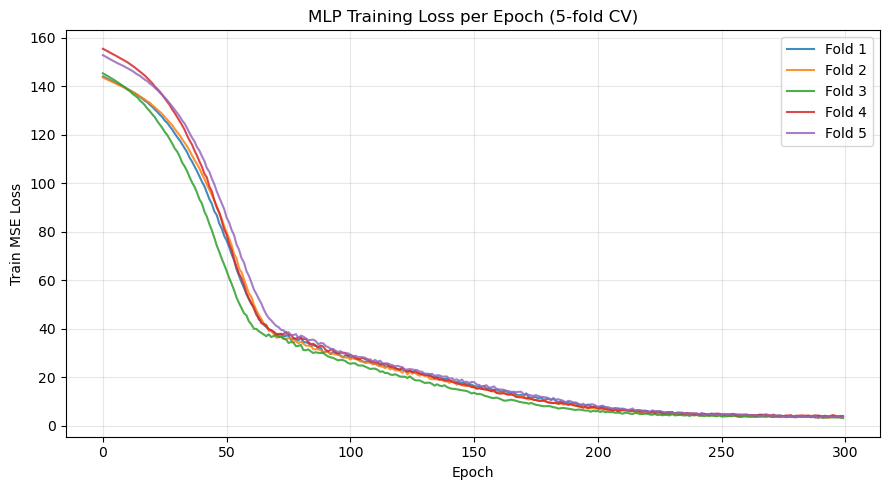

: 

In [ ]:
# Experiment 1: All features

X_all, y_all, cols_all = build_X_y(trial_data, mode='all')
all_metrics = run_mlp_cv(
    X_all,
    y_all,
    experiment_name='ALL FEATURES (actions + pupil + speech + EEG + others)',
    epochs=300,
    report_accuracy=True,  # strict/lenient accuracies
)

# Plot per-fold MLP training loss curves
plt.figure(figsize=(9, 5))
for i, losses in enumerate(getattr(run_mlp_cv, 'last_loss_histories', []), start=1):
    plt.plot(losses, label=f'Fold {i}', alpha=0.85)
plt.title('MLP Training Loss per Epoch (5-fold CV)')
plt.xlabel('Epoch')
plt.ylabel('Train MSE Loss')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Experiment 16: GCN with merged trial data (no averaging)

This GCN pipeline rebuilds trial-level data after the MLP experiments by merging all ring-level signals per trial, preserving multi-dimensional structure where possible.

- EEG is transformed to frequency domain as **64 FFT power bins** (0 Hz to Nyquist).
- EEG channels follow `chan_locs.sfp` lines 13, 17, 19: **`Fz`, `POz`, `Cz`**.
- Pupil is represented in frequency domain with **64 bins from 0 to 1 Hz** only.
- Other non-EEG sequence features are kept as temporal signals via fixed-length resampling (not mean/std averaging).
- The resulting trial feature vectors are used to build a kNN graph and train a GCN with 5-fold cross-validation.

GCN raw merged dataset: X1=(1074, 1), X2=(1074, 22, 8521), y=(1074,)

========== GCN (MERGED DATA, NO FLATTEN NON-1D) ==========
Starting 5-fold cross-validation on 1074 trials (device: cuda)

--- [Fold 1/5] ---
  Epoch    1/1200 | Train MSE: 59.3552
  Epoch   50/1200 | Train MSE: 13.4582
  Epoch  100/1200 | Train MSE: 12.2794
  Epoch  150/1200 | Train MSE: 10.3826
  Epoch  200/1200 | Train MSE: 8.7689
  Epoch  250/1200 | Train MSE: 6.6434
  Epoch  300/1200 | Train MSE: 5.4686
  Epoch  350/1200 | Train MSE: 4.0596
  Epoch  400/1200 | Train MSE: 4.3191
  Epoch  450/1200 | Train MSE: 4.0886
  Epoch  500/1200 | Train MSE: 3.6922
  Epoch  550/1200 | Train MSE: 3.4639
  Epoch  600/1200 | Train MSE: 3.2925
  Epoch  650/1200 | Train MSE: 3.2157
  Epoch  700/1200 | Train MSE: 2.9122
  Epoch  750/1200 | Train MSE: 3.1898
  Epoch  800/1200 | Train MSE: 3.1625
  Epoch  850/1200 | Train MSE: 2.9159
  Epoch  900/1200 | Train MSE: 2.8150
  Epoch  950/1200 | Train MSE: 3.2629
  Epoch 1000/1200 | Trai

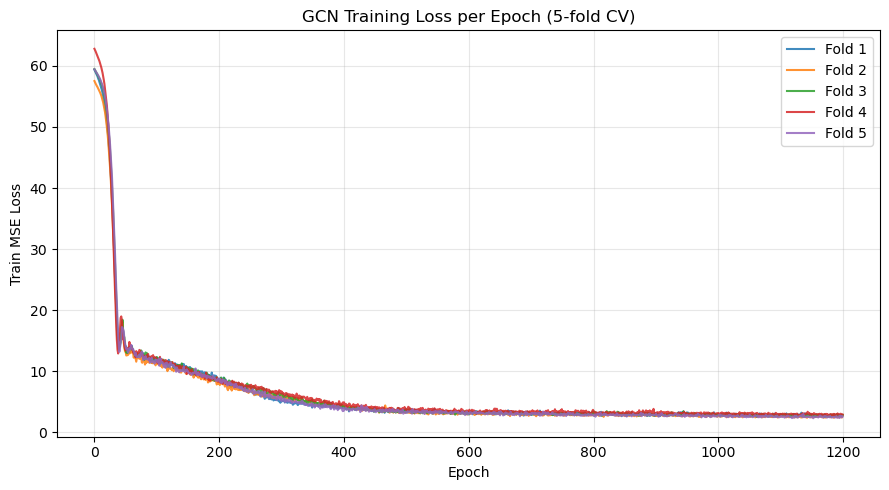

In [9]:
# Experiment 16: GCN with merged trial data (raw, no simplification)

# GCN input keeps merged time-series raw. No resampling and no FFT summarization.
# Arrays are only zero-padded (right side) so all trials share a common tensor size.

join_keys = ['teamID', 'sessionID', 'trialID', 'ringID']
trial_keys = ['teamID', 'sessionID', 'trialID']

# Keep GCN FFT settings exactly aligned with the MLP feature-extraction settings.
GCN_EEG_FS = EEG_FS
GCN_EEG_N_BINS = EEG_N_BINS
GCN_PUPIL_FS = PUPIL_FS
GCN_PUPIL_N_BINS = PUPIL_N_BINS
GCN_PUPIL_MAX_HZ = PUPIL_MAX_HZ


def _merge_sequence_list(values):
    """Merge ring-level arrays while preserving original dimensionality."""
    arrs = []
    for v in values:
        try:
            a = np.asarray(v, dtype=float)
        except Exception:
            continue
        if a.size == 0:
            continue
        arrs.append(a)

    if len(arrs) == 0:
        return None

    first_ndim = arrs[0].ndim
    if first_ndim == 1:
        one_d = [a.reshape(-1) for a in arrs]
        return np.concatenate(one_d, axis=0)

    if first_ndim == 2:
        ch = arrs[0].shape[0]
        aligned = []
        for a in arrs:
            if a.ndim == 2 and a.shape[0] == ch:
                aligned.append(a)
        if len(aligned) == 0:
            return None
        return np.concatenate(aligned, axis=1)

    return None


feature_schema = []
for col in feature_cols:
    sample = np.asarray(final.iloc[0][col], dtype=float)
    col_l = col.lower()
    is_eeg = 'eeg' in col_l
    is_pupil = 'pupil' in col_l

    if is_eeg:
        if sample.ndim == 2:
            feature_schema.append((col, 'eeg_2d_fft', len(EEG_SELECTED_CHANNELS)))
        else:
            feature_schema.append((col, 'eeg_1d_fft', 1))
    elif is_pupil:
        if sample.ndim == 2:
            feature_schema.append((col, 'pupil_2d_fft', sample.shape[0]))
        else:
            feature_schema.append((col, 'pupil_1d_fft', 1))
    else:
        if sample.ndim == 2:
            feature_schema.append((col, 'seq_2d', sample.shape[0]))
        else:
            feature_schema.append((col, 'seq_1d', 1))


def _to_raw_block(merged: np.ndarray, kind: str, base_ch: int) -> np.ndarray:
    """Return [channels, time_or_bins] block; EEG/pupil are converted to FFT bins."""
    if merged is None:
        if kind.startswith('eeg'):
            return np.zeros((base_ch, GCN_EEG_N_BINS), dtype=np.float32)
        if kind.startswith('pupil'):
            return np.zeros((base_ch, GCN_PUPIL_N_BINS), dtype=np.float32)
        return np.zeros((base_ch, 1), dtype=np.float32)

    arr = np.asarray(merged, dtype=float)
    if arr.ndim == 1:
        arr = arr.reshape(1, -1)

    arr = np.nan_to_num(arr)

    if kind == 'eeg_2d_fft':
        rows = []
        for ch_label in EEG_SELECTED_CHANNELS:
            ch_idx = EEG_CHANNEL_LABEL_TO_INDEX[ch_label]
            if ch_idx < arr.shape[0]:
                ch = arr[ch_idx]
            else:
                ch = np.zeros(arr.shape[1], dtype=float)
            rows.append(_fft_power_bins_1d(ch, fs=GCN_EEG_FS, n_bins=GCN_EEG_N_BINS))
        arr = np.vstack(rows)
    elif kind == 'eeg_1d_fft':
        bins = _fft_power_bins_1d(arr[0], fs=GCN_EEG_FS, n_bins=GCN_EEG_N_BINS)
        arr = bins.reshape(1, -1)
    elif kind == 'pupil_2d_fft':
        rows = []
        for ch_idx in range(arr.shape[0]):
            bins = _pupil_fft_bins_under_1hz(
                arr[ch_idx],
                fs=GCN_PUPIL_FS,
                f_max=GCN_PUPIL_MAX_HZ,
                n_bins=GCN_PUPIL_N_BINS,
            )
            rows.append(bins)
        arr = np.vstack(rows)
    elif kind == 'pupil_1d_fft':
        bins = _pupil_fft_bins_under_1hz(
            arr[0],
            fs=GCN_PUPIL_FS,
            f_max=GCN_PUPIL_MAX_HZ,
            n_bins=GCN_PUPIL_N_BINS,
        )
        arr = bins.reshape(1, -1)

    # Enforce expected channel count where applicable.
    if arr.shape[0] < base_ch:
        pad = np.zeros((base_ch - arr.shape[0], arr.shape[1]), dtype=float)
        arr = np.vstack([arr, pad])
    elif arr.shape[0] > base_ch:
        arr = arr[:base_ch, :]

    if arr.shape[1] == 0:
        arr = np.zeros((arr.shape[0], 1), dtype=float)

    return arr.astype(np.float32)


def build_trial_gcn_dataset(final_df: pd.DataFrame):
    diff_map = {'Easy': 1, 'Medium': 2, 'Hard': 3}

    X1_rows = []
    X2_rows = []
    y_rows = []

    grouped = final_df.groupby(trial_keys, sort=False)
    for _, g in grouped:
        diff_score = float(diff_map.get(g.iloc[0].get('difficulty', 'Medium'), 2))
        rings_passed = float(len(g))
        weighted_score = rings_passed * diff_score

        feat_blocks = []
        max_t_trial = 1
        for col, kind, base_ch in feature_schema:
            merged = _merge_sequence_list(g[col].values)
            block = _to_raw_block(merged, kind=kind, base_ch=base_ch)
            feat_blocks.append(block)
            if block.shape[1] > max_t_trial:
                max_t_trial = block.shape[1]

        trial_block = []
        for block in feat_blocks:
            if block.shape[1] < max_t_trial:
                pad = np.zeros((block.shape[0], max_t_trial - block.shape[1]), dtype=np.float32)
                block = np.hstack([block, pad])
            trial_block.append(block)

        X2_rows.append(np.concatenate(trial_block, axis=0).astype(np.float32))
        X1_rows.append(np.asarray([diff_score], dtype=np.float32))
        y_rows.append(weighted_score)

    max_ch = max(x.shape[0] for x in X2_rows)
    max_t = max(x.shape[1] for x in X2_rows)

    X2_padded = []
    for x in X2_rows:
        if x.shape[1] < max_t:
            x = np.hstack([x, np.zeros((x.shape[0], max_t - x.shape[1]), dtype=np.float32)])
        if x.shape[0] < max_ch:
            x = np.vstack([x, np.zeros((max_ch - x.shape[0], x.shape[1]), dtype=np.float32)])
        X2_padded.append(x.astype(np.float32))

    X1_out = np.vstack(X1_rows)
    X2_out = np.stack(X2_padded, axis=0)
    y_out = np.asarray(y_rows, dtype=np.float32)
    return X1_out, X2_out, y_out


X1_gcn, X2_gcn, y_gcn = build_trial_gcn_dataset(final)
print(f"GCN raw merged dataset: X1={X1_gcn.shape}, X2={X2_gcn.shape}, y={y_gcn.shape}")


def build_knn_adjacency(X1: np.ndarray, X2: np.ndarray, k: int = 10) -> np.ndarray:
    n = X1.shape[0]

    # Distance from 1D branch
    x1_norm = np.sum(X1 * X1, axis=1, keepdims=True)
    d1 = x1_norm + x1_norm.T - 2.0 * (X1 @ X1.T)

    # Distance from 2D branch without flattening raw arrays
    x2_norm = np.sum(X2 * X2, axis=(1, 2), keepdims=False)
    x2_dot = np.tensordot(X2, X2, axes=([1, 2], [1, 2]))
    d2 = x2_norm[:, None] + x2_norm[None, :] - 2.0 * x2_dot

    dists = np.maximum(d1 + d2, 0.0)
    np.fill_diagonal(dists, np.inf)

    k_eff = min(k, n - 1)
    knn_idx = np.argpartition(dists, kth=k_eff, axis=1)[:, :k_eff]

    A = np.zeros((n, n), dtype=np.float32)
    rows = np.repeat(np.arange(n), k_eff)
    A[rows, knn_idx.reshape(-1)] = 1.0
    A = np.maximum(A, A.T)
    np.fill_diagonal(A, 1.0)
    return A


def normalize_adjacency(A: np.ndarray) -> np.ndarray:
    deg = np.sum(A, axis=1)
    deg_inv_sqrt = np.power(deg, -0.5, where=deg > 0)
    deg_inv_sqrt[deg == 0] = 0.0
    D_inv_sqrt = np.diag(deg_inv_sqrt.astype(np.float32))
    return D_inv_sqrt @ A @ D_inv_sqrt


class GraphConv(nn.Module):
    def __init__(self, in_dim: int, out_dim: int):
        super().__init__()
        self.linear = nn.Linear(in_dim, out_dim)

    def forward(self, x: torch.Tensor, a_hat: torch.Tensor) -> torch.Tensor:
        return self.linear(a_hat @ x)


class MergedDataGCN(nn.Module):
    def __init__(self, x1_dim: int, x2_channels: int, hidden_size: int = 96, dropout: float = 0.25):
        super().__init__()

        self.x2_encoder = nn.Sequential(
            nn.Conv1d(x2_channels, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv1d(64, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
        )

        fused_dim = x1_dim + 32
        self.gc1 = GraphConv(fused_dim, hidden_size)
        self.gc2 = GraphConv(hidden_size, hidden_size // 2)
        self.out = nn.Linear(hidden_size // 2, 1)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x1: torch.Tensor, x2: torch.Tensor, a_hat: torch.Tensor) -> torch.Tensor:
        x2_latent = self.x2_encoder(x2).squeeze(-1)
        x = torch.cat([x1, x2_latent], dim=1)
        x = torch.relu(self.gc1(x, a_hat))
        x = self.dropout(x)
        x = torch.relu(self.gc2(x, a_hat))
        x = self.dropout(x)
        return self.out(x).squeeze(1)


def run_gcn_cv(
    X1: np.ndarray,
    X2: np.ndarray,
    y: np.ndarray,
    experiment_name: str = 'GCN (MERGED DATA, NO FLATTEN NON-1D)',
    epochs: int = 1200,
    lr: float = 1e-3,
    k_neighbors: int = 12,
):
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    fold_metrics = []
    fold_train_losses = []

    print(f"\n========== {experiment_name} ==========")
    print(f"Starting 5-fold cross-validation on {len(y)} trials (device: {device})")

    for fold, (train_idx, test_idx) in enumerate(kf.split(X1), start=1):
        print(f"\n--- [Fold {fold}/5] ---")

        # Scale 1D branch with train split only
        scaler_1d = StandardScaler()
        scaler_1d.fit(X1[train_idx])
        X1_scaled = scaler_1d.transform(X1).astype(np.float32)

        # Scale 2D branch per [channel, time] element with train-only stats
        mu2 = X2[train_idx].mean(axis=0, keepdims=True)
        sd2 = X2[train_idx].std(axis=0, keepdims=True)
        sd2 = np.where(sd2 < 1e-8, 1.0, sd2)
        X2_scaled = ((X2 - mu2) / sd2).astype(np.float32)

        A = build_knn_adjacency(X1_scaled, X2_scaled, k=k_neighbors)
        A_hat = normalize_adjacency(A)

        x1_t = torch.tensor(X1_scaled, dtype=torch.float32, device=device)
        x2_t = torch.tensor(X2_scaled, dtype=torch.float32, device=device)
        y_t = torch.tensor(y, dtype=torch.float32, device=device)
        a_t = torch.tensor(A_hat, dtype=torch.float32, device=device)

        train_mask = torch.zeros(len(y), dtype=torch.bool, device=device)
        test_mask = torch.zeros(len(y), dtype=torch.bool, device=device)
        train_mask[train_idx] = True
        test_mask[test_idx] = True

        model = MergedDataGCN(x1_dim=X1.shape[1], x2_channels=X2.shape[1]).to(device)
        optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-3)
        criterion = nn.MSELoss()
        epoch_losses = []

        model.train()
        for epoch in range(epochs):
            optimizer.zero_grad()
            pred_all = model(x1_t, x2_t, a_t)
            loss = criterion(pred_all[train_mask], y_t[train_mask])
            loss.backward()
            optimizer.step()
            epoch_losses.append(float(loss.item()))

            if (epoch + 1) % 50 == 0 or epoch == 0:
                print(f"  Epoch {epoch + 1:>4}/{epochs} | Train MSE: {loss.item():.4f}")

        fold_train_losses.append(epoch_losses)

        model.eval()
        with torch.no_grad():
            pred_np = model(x1_t, x2_t, a_t).detach().cpu().numpy()

        y_true = y[test_idx]
        y_pred = pred_np[test_idx]

        mse = float(np.mean((y_true - y_pred) ** 2))
        rmse = float(np.sqrt(mse))
        mae = float(np.mean(np.abs(y_true - y_pred)))
        ss_res = float(np.sum((y_true - y_pred) ** 2))
        ss_tot = float(np.sum((y_true - np.mean(y_true)) ** 2))
        r2 = 0.0 if ss_tot == 0.0 else 1.0 - ss_res / ss_tot

        fold_metrics.append({'mse': mse, 'rmse': rmse, 'mae': mae, 'r2': r2})
        print(f"  -> Fold {fold} | MSE: {mse:.3f} | RMSE: {rmse:.3f} | MAE: {mae:.3f} | R^2: {r2:.3f}")

    mse_vals = np.array([m['mse'] for m in fold_metrics])
    rmse_vals = np.array([m['rmse'] for m in fold_metrics])
    mae_vals = np.array([m['mae'] for m in fold_metrics])
    r2_vals = np.array([m['r2'] for m in fold_metrics])

    print("\n=============================================")
    print(f"FINAL RESULTS: {experiment_name}")
    print("=============================================")
    print(f"MSE   : {mse_vals.mean():.3f} ± {mse_vals.std():.3f}")
    print(f"RMSE  : {rmse_vals.mean():.3f} ± {rmse_vals.std():.3f}")
    print(f"MAE   : {mae_vals.mean():.3f} ± {mae_vals.std():.3f}")
    print(f"R^2   : {r2_vals.mean():.3f} ± {r2_vals.std():.3f}")
    print("=============================================\n")

    run_gcn_cv.last_loss_histories = fold_train_losses
    return fold_metrics


gcn_merged_metrics = run_gcn_cv(X1_gcn, X2_gcn, y_gcn, epochs=1200, lr=1e-3, k_neighbors=12)

# Plot per-fold GCN training loss curves
plt.figure(figsize=(9, 5))
for i, losses in enumerate(getattr(run_gcn_cv, 'last_loss_histories', []), start=1):
    plt.plot(losses, label=f'Fold {i}', alpha=0.85)
plt.title('GCN Training Loss per Epoch (5-fold CV)')
plt.xlabel('Epoch')
plt.ylabel('Train MSE Loss')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [10]:
# GCN Overfitting Analysis (Performance Gap)
print('='*40)
print('GCN PERFORMANCE GAP ANALYSIS')
print('='*40)

# Extract final training losses from the history and compare with test results
final_train_mses = [hist[-1] for hist in run_gcn_cv.last_loss_histories]
final_test_mses = [m['mse'] for m in gcn_merged_metrics]

mean_train = np.mean(final_train_mses)
mean_test = np.mean(final_test_mses)
gap = (mean_test - mean_train) / mean_train * 100 if mean_train > 0 else 0

print(f'Mean Final Train MSE: {mean_train:.4f}')
print(f'Mean Final Test MSE:  {mean_test:.4f}')
print(f'Gap: {gap:.2f}% (Test MSE vs Train MSE)')

if gap > 20:
    print('STATUS: Potential Overfitting detected. The model performs significantly better on training data.')
elif gap < 0:
    print('STATUS: Underfitting or high regularization. Test performance is better than training.')
else:
    print('STATUS: Good Generalization. The model generalizes well to unseen data.')


GCN PERFORMANCE GAP ANALYSIS
Mean Final Train MSE: 2.8017
Mean Final Test MSE:  2.1695
Gap: -22.56% (Test MSE vs Train MSE)
STATUS: Underfitting or high regularization. Test performance is better than training.
